正在加载 MNIST 数据集...
训练集大小: (60000, 784), 测试集大小: (10000, 784)
正在训练 10 个类别的高斯生成模型...
正在计算测试集的对数似然矩阵 (这可能需要几十秒)...
计算完成！耗时: 0.86 秒

基于最大似然的分类准确率: 77.03%


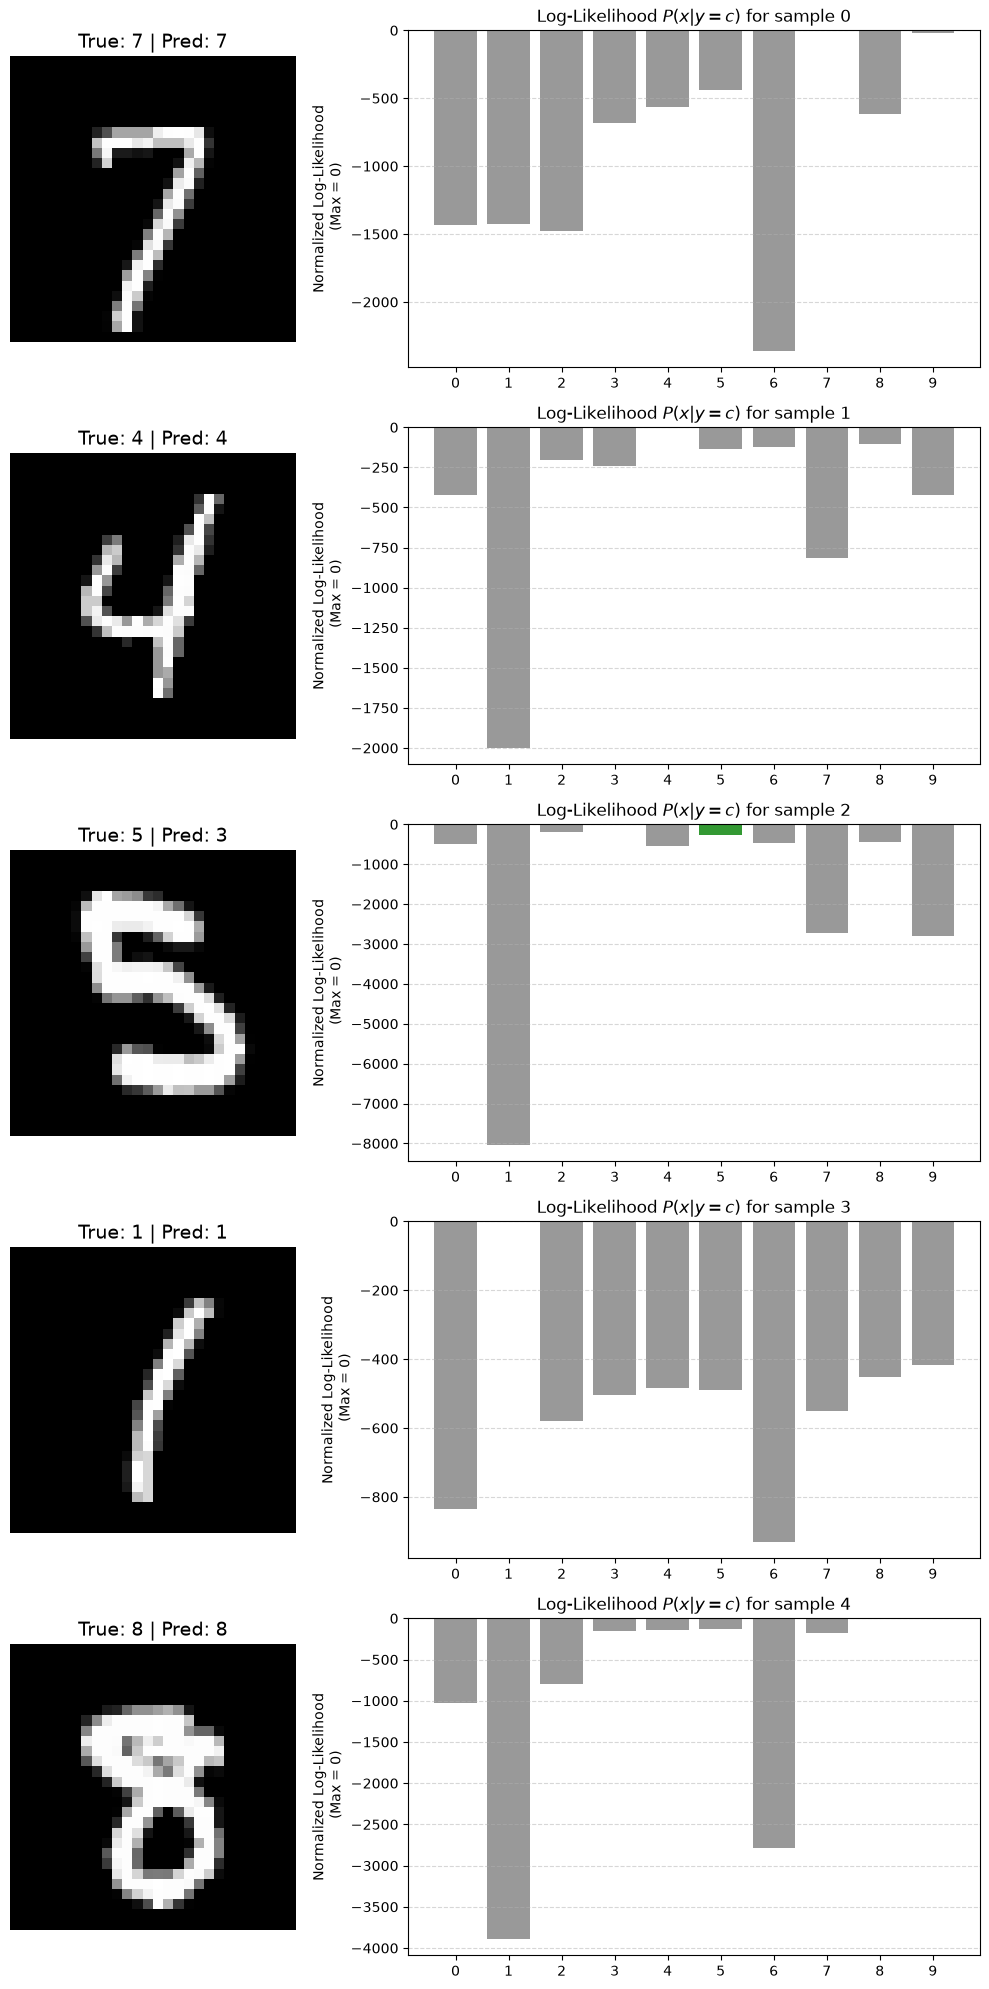

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import time

def main():
    # ==========================================
    # 1. 加载并划分 MNIST 数据集
    # ==========================================
    print("正在加载 MNIST 数据集...")
    mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
    X, y = mnist["data"], mnist["target"].astype(int)
    
    # 划分训练集（用于建立类别模型）和测试集（用于计算似然）
    # MNIST 标准划分：60000 训练，10000 测试
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=10000, random_state=42, stratify=y
    )
    
    # 归一化到 [0, 1] 区间
    X_train = X_train / 255.0
    X_test = X_test / 255.0
    
    print(f"训练集大小: {X_train.shape}, 测试集大小: {X_test.shape}")

    # ==========================================
    # 2. 训练类别条件模型 (估计每个类别的均值和方差)
    # ==========================================
    print("正在训练 10 个类别的高斯生成模型...")
    classes = np.arange(10)
    n_features = X_train.shape[1] # 784
    
    # 存储每个类别的均值和方差，形状为 (10, 784)
    mu = np.zeros((10, n_features))
    var = np.zeros((10, n_features))
    priors = np.zeros(10) # 先验概率 P(y=c)
    
    for c in classes:
        # 提取属于类别 c 的所有训练图像
        X_c = X_train[y_train == c]
        priors[c] = X_c.shape[0] / X_train.shape[0]
        
        # 计算每个像素的均值和方差
        mu[c] = np.mean(X_c, axis=0)
        var[c] = np.var(X_c, axis=0)
        
    # 【关键】拉普拉斯平滑 / 正则化：防止方差为 0 导致除以零错误
    epsilon = 1e-3
    var = var + epsilon 

    # ==========================================
    # 3. 计算测试集在每个类别下的对数似然
    # ==========================================
    print("正在计算测试集的对数似然矩阵 (这可能需要几十秒)...")
    start_time = time.time()
    
    n_test = X_test.shape[0]
    # 初始化对数似然矩阵，形状为 (10000, 10)
    log_likelihoods = np.zeros((n_test, 10))
    
    # 高斯分布的对数概率密度函数公式：
    # log P(x_j | c) = -0.5 * [ log(2*pi*var) + (x_j - mu)^2 / var ]
    
    # 利用 NumPy 广播机制进行高效矩阵运算，避免使用缓慢的 for 循环
    # X_test 形状: (10000, 784) -> 扩展为 (10000, 1, 784)
    # mu 形状: (10, 784) -> 扩展为 (1, 10, 784)
    # var 形状: (10, 784) -> 扩展为 (1, 10, 784)
    
    X_test_expanded = X_test[:, np.newaxis, :] 
    
    # 计算每个像素的对数似然，形状为 (10000, 10, 784)
    log_probs = -0.5 * (np.log(2 * np.pi * var) + ((X_test_expanded - mu) ** 2) / var)
    
    # 假设像素条件独立，对 784 个像素的对数似然求和，得到整张图的对数似然
    # 结果形状: (10000, 10)
    log_likelihoods = np.sum(log_probs, axis=2)
    
    end_time = time.time()
    print(f"计算完成！耗时: {end_time - start_time:.2f} 秒")

    # ==========================================
    # 4. 结果分析与可视化
    # ==========================================
    # 根据最大似然估计 (MLE) 进行预测：选择对数似然最大的类别
    y_pred = np.argmax(log_likelihoods, axis=1)
    accuracy = np.mean(y_pred == y_test)
    print(f"\n基于最大似然的分类准确率: {accuracy:.2%}")
    
    # 可视化前 5 张测试图像的对数似然分布
    plot_likelihood_heatmap(X_test, y_test, log_likelihoods, num_samples=5)

def plot_likelihood_heatmap(images, true_labels, log_liks, num_samples=5):
    """绘制测试图像及其在各个类别下的对数似然热力图"""
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples), 
                             gridspec_kw={'width_ratios': [1, 2]})
    
    for i in range(num_samples):
        img = images[i].reshape(28, 28)
        true_label = true_labels[i]
        liks = log_liks[i]
        pred_label = np.argmax(liks)
        
        # 左侧：绘制原始图像
        axes[i, 0].imshow(img, cmap='gray')
        axes[i, 0].set_title(f"True: {true_label} | Pred: {pred_label}", fontsize=14)
        axes[i, 0].axis('off')
        
        # 右侧：绘制对数似然条形图/热力图
        # 为了可视化，我们将对数似然进行归一化（减去最大值，使最大值为0）
        liks_normalized = liks - np.max(liks) 
        
        colors = ['green' if j == true_label else 'red' if j == pred_label else 'gray' for j in range(10)]
        axes[i, 1].bar(range(10), liks_normalized, color=colors, alpha=0.8)
        axes[i, 1].set_xticks(range(10))
        axes[i, 1].set_ylabel("Normalized Log-Likelihood\n (Max = 0)")
        axes[i, 1].set_title(f"Log-Likelihood $P(x|y=c)$ for sample {i}")
        axes[i, 1].grid(axis='y', linestyle='--', alpha=0.5)
        
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

正在加载 MNIST 数据集...
数据集加载完成！总样本数: 70000
正在计算 0-9 每个类别的平均图像和标准差图像...
计算完成！耗时: 0.85 秒
正在生成可视化图表...


C:\Users\yuhao.bian\AppData\Local\Temp\ipykernel_32156\949601976.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


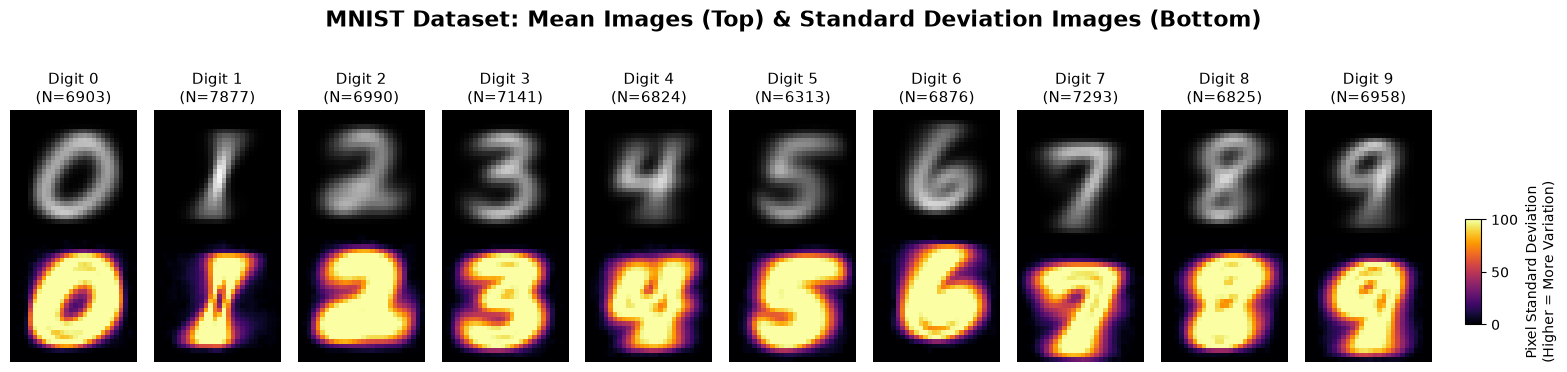

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
import time

def main():
    # ==========================================
    # 1. 加载 MNIST 数据集
    # ==========================================
    print("正在加载 MNIST 数据集...")
    # 加载完整的 70,000 张图像
    mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
    X, y = mnist["data"], mnist["target"].astype(int)
    print(f"数据集加载完成！总样本数: {X.shape[0]}")

    # ==========================================
    # 2. 计算每个数字类别的均值和标准差
    # ==========================================
    print("正在计算 0-9 每个类别的平均图像和标准差图像...")
    start_time = time.time()
    
    mean_images = np.zeros((10, 28, 28))
    std_images = np.zeros((10, 28, 28))
    class_counts = np.zeros(10, dtype=int)

    for digit in range(10):
        # 提取属于当前数字的所有图像
        X_digit = X[y == digit]
        class_counts[digit] = X_digit.shape[0]
        
        # 按像素位置计算均值和标准差，并重塑为 28x28 图像
        mean_images[digit] = np.mean(X_digit, axis=0).reshape(28, 28)
        std_images[digit] = np.std(X_digit, axis=0).reshape(28, 28)
        
    end_time = time.time()
    print(f"计算完成！耗时: {end_time - start_time:.2f} 秒")

    # ==========================================
    # 3. 可视化展示
    # ==========================================
    print("正在生成可视化图表...")
    
    # 创建 2行 10列 的画布
    fig, axes = plt.subplots(2, 10, figsize=(16, 3.5))
    fig.suptitle('MNIST Dataset: Mean Images (Top) & Standard Deviation Images (Bottom)', 
                 fontsize=16, fontweight='bold', y=1.05)

    for digit in range(10):
        # --- 第一行：绘制平均图像 (Mean) ---
        ax_mean = axes[0, digit]
        # 使用灰度图 (gray)，范围 0-255
        im_mean = ax_mean.imshow(mean_images[digit], cmap='gray', vmin=0, vmax=255)
        ax_mean.set_title(f"Digit {digit}\n(N={class_counts[digit]})", fontsize=11)
        ax_mean.axis('off') # 隐藏坐标轴

        # --- 第二行：绘制标准差图像 (Std) ---
        ax_std = axes[1, digit]
        # 使用热力图色图 (inferno 或 hot)，高亮显示高方差区域
        # vmin=0, vmax=100 用于统一所有标准差图的颜色标尺 (MNIST像素标准差通常在0-120之间)
        im_std = ax_std.imshow(std_images[digit], cmap='inferno', vmin=0, vmax=100)
        ax_std.axis('off')

    # 添加颜色条 (Colorbar) 以解释标准差图的颜色含义
    cbar_ax = fig.add_axes([0.92, 0.15, 0.01, 0.3]) # [left, bottom, width, height]
    cbar = fig.colorbar(im_std, cax=cbar_ax)
    cbar.set_label('Pixel Standard Deviation\n(Higher = More Variation)', fontsize=10)

    plt.tight_layout()
    plt.subplots_adjust(right=0.9) # 为 colorbar 留出空间
    plt.show()

if __name__ == "__main__":
    main()

加载数据中...


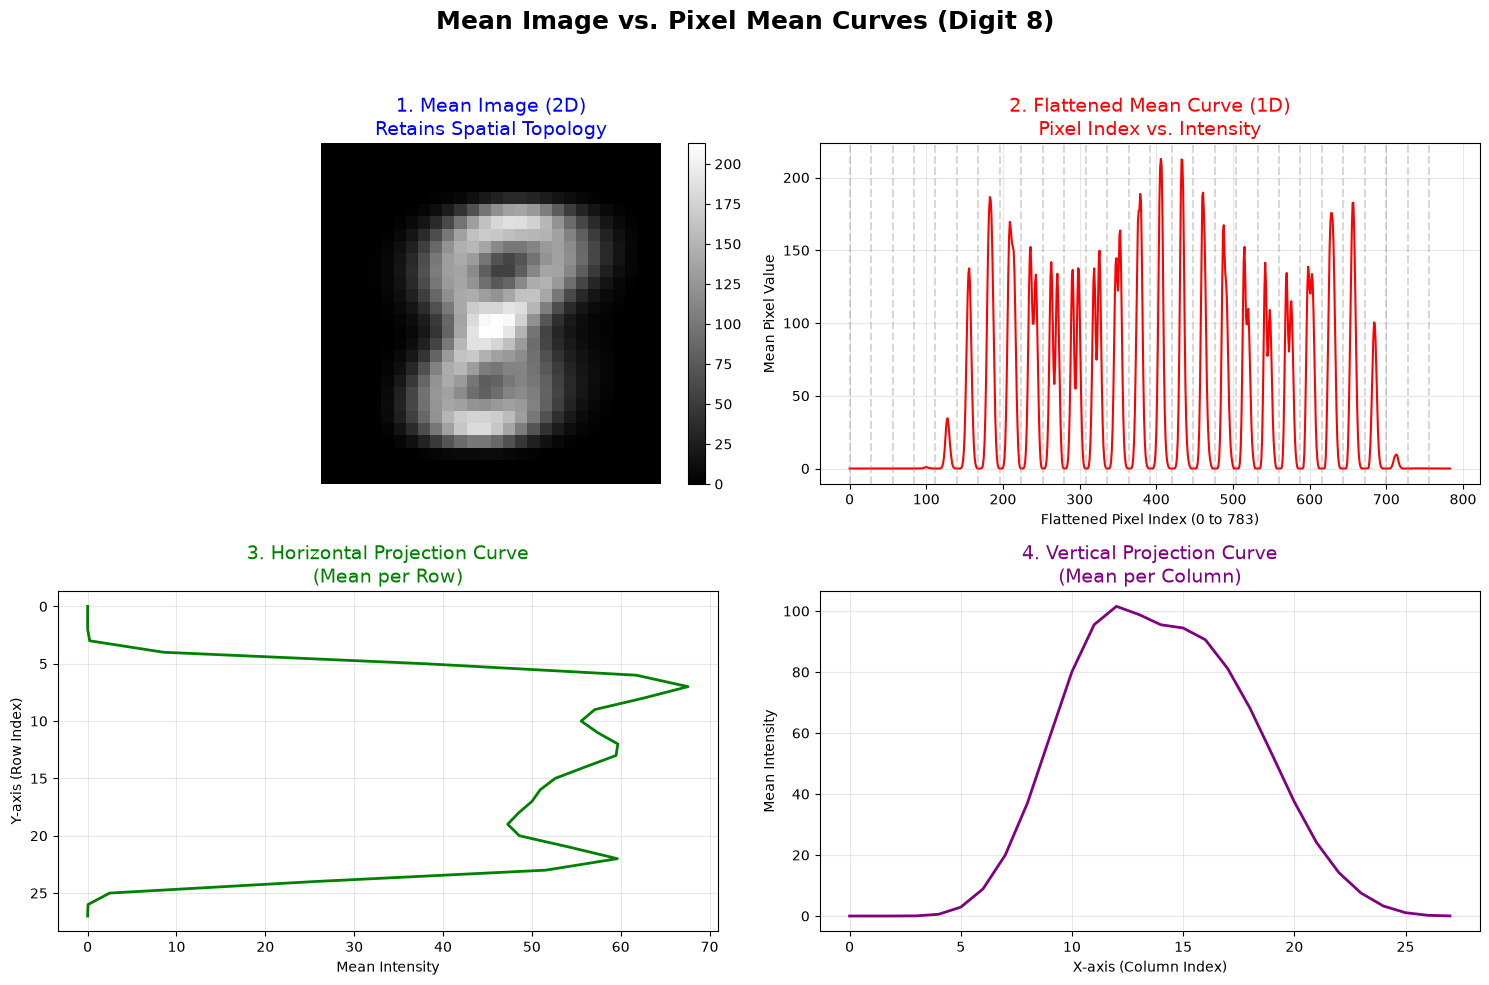

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

# 1. 加载数据并提取数字 '8' (以数字8为例，因为它的结构最复杂)
print("加载数据中...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist["data"], mnist["target"].astype(int)
X_digit = X[y == 8] # 提取所有数字 8

# 2. 计算核心数据：784维的像素均值向量 (数学本质)
mean_vector_1d = np.mean(X_digit, axis=0) 

# 3. 衍生数据
mean_image_2d = mean_vector_1d.reshape(28, 28)             # 重塑为 2D 平均图像
horizontal_profile = np.mean(mean_image_2d, axis=1)        # 水平投影 (每行的均值)
vertical_profile = np.mean(mean_image_2d, axis=0)          # 垂直投影 (每列的均值)

# 4. 可视化对比
fig = plt.figure(figsize=(15, 10))
fig.suptitle('Mean Image vs. Pixel Mean Curves (Digit 8)', fontsize=18, fontweight='bold')

# 图1：平均图像 (2D)
ax1 = fig.add_subplot(2, 2, 1)
im = ax1.imshow(mean_image_2d, cmap='gray')
ax1.set_title('1. Mean Image (2D)\nRetains Spatial Topology', fontsize=14, color='blue')
ax1.axis('off')
fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)

# 图2：展平后的 784 维均值曲线 (1D)
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(mean_vector_1d, color='red', linewidth=1.5)
ax2.set_title('2. Flattened Mean Curve (1D)\nPixel Index vs. Intensity', fontsize=14, color='red')
ax2.set_xlabel('Flattened Pixel Index (0 to 783)')
ax2.set_ylabel('Mean Pixel Value')
ax2.grid(True, alpha=0.3)
# 标记出图像的大致行边界
for i in range(0, 784, 28):
    ax2.axvline(x=i, color='gray', linestyle='--', alpha=0.3)

# 图3 & 图4：行/列投影曲线 (OCR常用)
ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(horizontal_profile, range(28), color='green', linewidth=2) # 注意Y轴反转以匹配图像坐标
ax3.set_title('3. Horizontal Projection Curve\n(Mean per Row)', fontsize=14, color='green')
ax3.set_ylabel('Y-axis (Row Index)')
ax3.set_xlabel('Mean Intensity')
ax3.invert_yaxis() # 反转Y轴，使其与图像的上下方向一致
ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(range(28), vertical_profile, color='purple', linewidth=2)
ax4.set_title('4. Vertical Projection Curve\n(Mean per Column)', fontsize=14, color='purple')
ax4.set_xlabel('X-axis (Column Index)')
ax4.set_ylabel('Mean Intensity')
ax4.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

加载数据中...
共提取 6824 张数字 4 的图像。


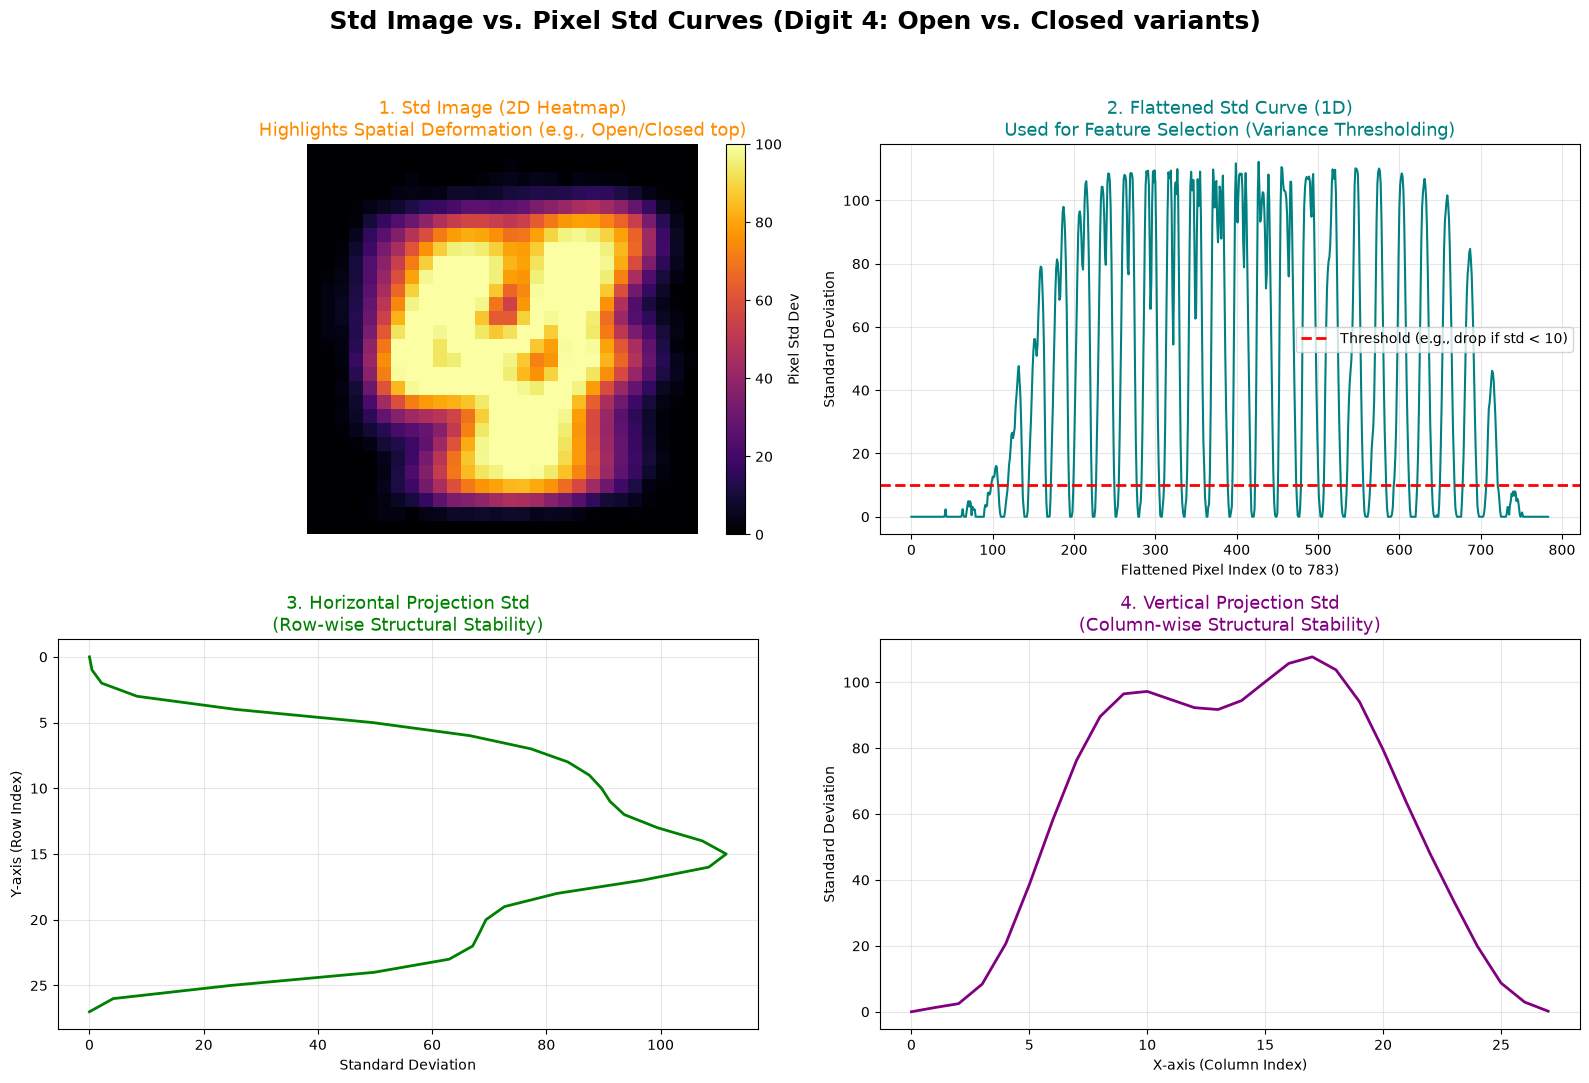

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

# 1. 加载数据并提取数字 '4' (存在开口/闭口两种写法，形变特征明显)
print("加载数据中...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist["data"], mnist["target"].astype(int)
X_digit = X[y == 4] 
print(f"共提取 {X_digit.shape[0]} 张数字 4 的图像。")

# 2. 计算核心数据：784维的像素标准差向量 (数学本质)
std_vector_1d = np.std(X_digit, axis=0) 

# 3. 衍生数据
std_image_2d = std_vector_1d.reshape(28, 28)             # 重塑为 2D 标准差图像
horizontal_std = np.std(X_digit.reshape(-1, 28, 28), axis=(0, 2)) # 每一行的全局标准差
vertical_std = np.std(X_digit.reshape(-1, 28, 28), axis=(0, 1))   # 每一列的全局标准差

# 4. 可视化对比
fig = plt.figure(figsize=(16, 11))
fig.suptitle('Std Image vs. Pixel Std Curves (Digit 4: Open vs. Closed variants)', 
             fontsize=18, fontweight='bold')

# 图1：标准差图像 (2D)
ax1 = fig.add_subplot(2, 2, 1)
im = ax1.imshow(std_image_2d, cmap='inferno', vmin=0, vmax=100)
ax1.set_title('1. Std Image (2D Heatmap)\nHighlights Spatial Deformation (e.g., Open/Closed top)', 
              fontsize=13, color='darkorange')
ax1.axis('off')
fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04, label='Pixel Std Dev')

# 图2：展平后的 784 维标准差曲线 (1D)
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(std_vector_1d, color='teal', linewidth=1.5)
ax2.set_title('2. Flattened Std Curve (1D)\nUsed for Feature Selection (Variance Thresholding)', 
              fontsize=13, color='teal')
ax2.set_xlabel('Flattened Pixel Index (0 to 783)')
ax2.set_ylabel('Standard Deviation')
ax2.grid(True, alpha=0.3)
# 画一条阈值线，演示如何剔除低方差特征
ax2.axhline(y=10, color='red', linestyle='--', linewidth=2, label='Threshold (e.g., drop if std < 10)')
ax2.legend()

# 图3 & 图4：行/列投影标准差曲线
ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(horizontal_std, range(28), color='green', linewidth=2) 
ax3.set_title('3. Horizontal Projection Std\n(Row-wise Structural Stability)', fontsize=13, color='green')
ax3.set_ylabel('Y-axis (Row Index)')
ax3.set_xlabel('Standard Deviation')
ax3.invert_yaxis() 
ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(range(28), vertical_std, color='purple', linewidth=2)
ax4.set_title('4. Vertical Projection Std\n(Column-wise Structural Stability)', fontsize=13, color='purple')
ax4.set_xlabel('X-axis (Column Index)')
ax4.set_ylabel('Standard Deviation')
ax4.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

正在加载 MNIST 数据集...


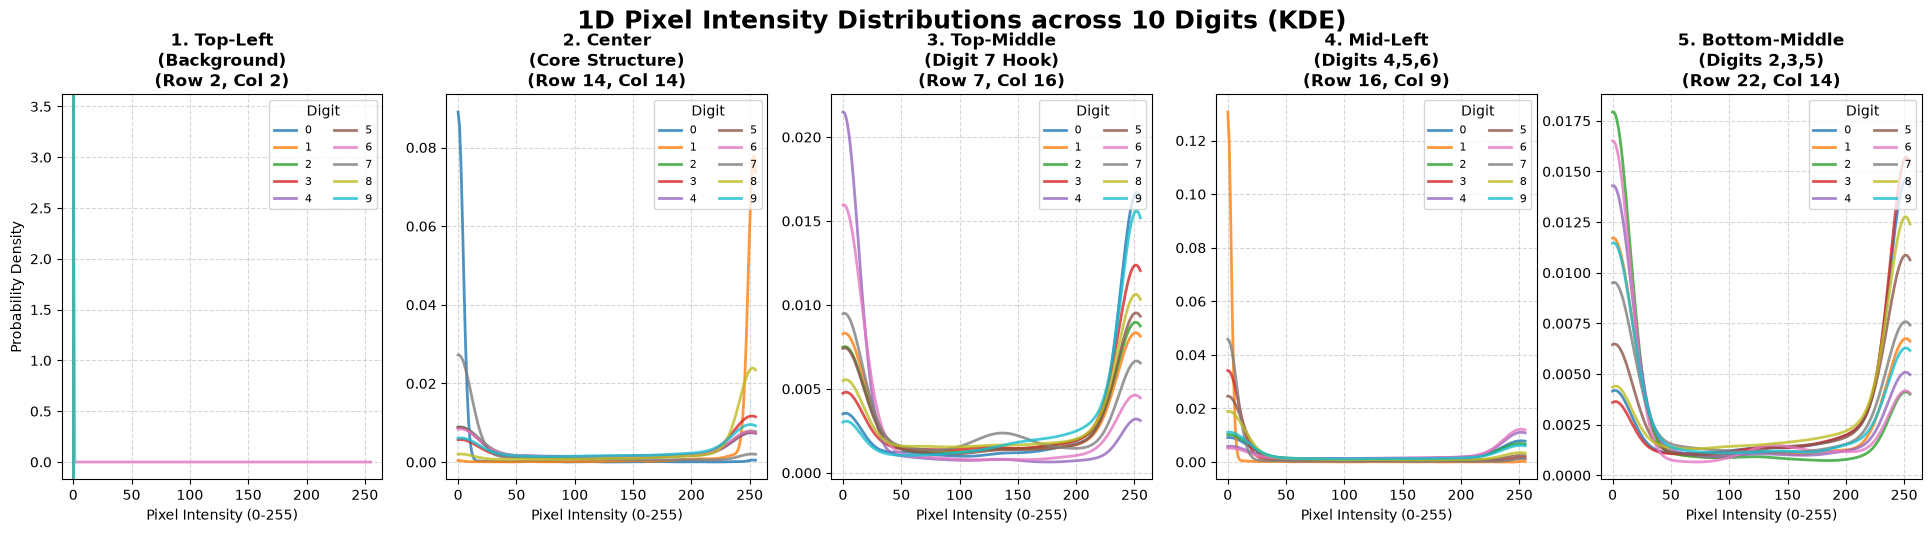

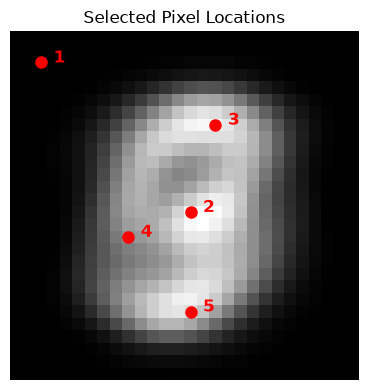

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from scipy.stats import gaussian_kde
import warnings

def main():
    warnings.filterwarnings('ignore')
    print("正在加载 MNIST 数据集...")
    mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
    X, y = mnist["data"], mnist["target"].astype(int)
    
    # 定义 5 个具有代表性的像素位置 (行, 列)
    # 1. 左上角背景：永远是黑色 (0)
    # 2. 图像正中心：区分 '0' (空心) 和 '8' (实心交叉)
    # 3. 中上部区域：数字 '7' 的横线特征区
    # 4. 中左侧区域：数字 '4', '5', '6' 的左侧笔画区
    # 5. 中下部区域：数字 '2', '3', '5', '8' 的底部弯钩区
    selected_pixels = {
        "Top-Left\n(Background)": (2, 2),
        "Center\n(Core Structure)": (14, 14),
        "Top-Middle\n(Digit 7 Hook)": (7, 16),
        "Mid-Left\n(Digits 4,5,6)": (16, 9),
        "Bottom-Middle\n(Digits 2,3,5)": (22, 14)
    }
    
    fig, axes = plt.subplots(1, 5, figsize=(24, 5), sharey=False)
    fig.suptitle('1D Pixel Intensity Distributions across 10 Digits (KDE)', 
                 fontsize=18, fontweight='bold', y=1.05)
    
    # 获取 10 种不同的颜色
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    
    # 创建一个辅助图，在 MNIST 平均图像上标记这 5 个像素的位置
    fig_map, ax_map = plt.subplots(figsize=(4, 4))
    mean_img = np.mean(X, axis=0).reshape(28, 28)
    ax_map.imshow(mean_img, cmap='gray')
    ax_map.set_title("Selected Pixel Locations", fontsize=12)
    ax_map.axis('off')

    for idx, (name, (r, c)) in enumerate(selected_pixels.items()):
        ax = axes[idx]
        pixel_idx = r * 28 + c
        
        # 在辅助图上标记红点
        ax_map.plot(c, r, 'ro', markersize=8)
        ax_map.text(c + 1, r, str(idx + 1), color='red', fontsize=12, fontweight='bold')
        
        # 绘制每个数字类别在该像素上的 KDE 分布
        for digit in range(10):
            # 提取该类别下该像素的所有值
            pixel_values = X[y == digit, pixel_idx]
            
            # 如果方差为 0 (例如纯背景)，KDE 会报错，需要特殊处理
            if np.std(pixel_values) < 1e-5:
                # 画一条垂直线表示狄拉克 Delta 分布
                ax.axvline(x=pixel_values[0], color=colors[digit], 
                           linestyle='-', linewidth=2, alpha=0.8, label=f'{digit}')
            else:
                # 计算并绘制核密度估计曲线
                kde = gaussian_kde(pixel_values, bw_method=0.15)
                x_grid = np.linspace(0, 255, 200)
                ax.plot(x_grid, kde(x_grid), color=colors[digit], 
                        linewidth=2, alpha=0.8, label=f'{digit}')
                
        ax.set_title(f"{idx+1}. {name}\n(Row {r}, Col {c})", fontsize=12, fontweight='bold')
        ax.set_xlabel("Pixel Intensity (0-255)")
        if idx == 0:
            ax.set_ylabel("Probability Density")
        ax.set_xlim(-10, 265)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(title="Digit", fontsize=8, loc='upper right', ncol=2)

    plt.tight_layout()
    
    # 显示位置标记图
    plt.figure(fig_map.number)
    plt.tight_layout()
    
    plt.show()

if __name__ == "__main__":
    main()